INSTALL LIBRARY SASTRAWI

In [ ]:
!pip install Sastrawi openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00


IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

LOAD DATASET

In [ ]:
df = pd.read_excel('/content/dataset_final_mbg.xlsx')

In [ ]:
df.head()

,Timestamp,KESEGARAN,LABEL KESEGARAN,GIZI,LABEL GIZI,RASA,LABEL RASA,PORSI,LABEL PORSI
0,2026-05-26 10:29:14.620,cukup segar dan lumayan enak walau kadang ada ...,-1,cukup karena dalam satu waktu memiliki banyak ...,1,enak dan program mbg cukup membantu,1,cukup,1
1,2026-05-26 10:32:28.612,"kadang segar, kadang ada yang asem bu, buahnya...",-1,sudah sesuai 4 sehat 5 sempurna,1,"kadang ada yang hambar, dan kecut",-1,sudah pas,1
2,2026-05-26 10:33:50.958,"terkadang segar, terkadang udah agak asem/bau ...",-1,menurut saya kurang memenuhi asupan gizi haria...,-1,"tergantung sppg, kadang enak kadang engga. ya ...",-1,"cukup buat sekali makan, nasi nya pas, lauknya...",1
3,2026-05-26 10:35:44.330,kadang segar kadang engga,0,enak bergizi,1,kadang enak kadang engga,0,porsinya kurang,-1
4,2026-05-26 10:37:15.914,Cukup segar,1,kandungan gizinya seimbang,1,"rasa makan enak, kaya rasa",1,porsinya cukup dan pas,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timestamp        169 non-null    datetime64[ns]
 1   KESEGARAN        169 non-null    object        
 2   LABEL KESEGARAN  169 non-null    int64         
 3   GIZI             169 non-null    object        
 4   LABEL GIZI       169 non-null    int64         
 5   RASA             169 non-null    object        
 6   LABEL RASA       169 non-null    int64         
 7   PORSI            169 non-null    object        
 8   LABEL PORSI      169 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 12.0+ KB


CEK MISSING VALUE

In [ ]:
df.isnull().sum()

,0
Timestamp,0
KESEGARAN,0
LABEL KESEGARAN,0
GIZI,0
LABEL GIZI,0
RASA,0
LABEL RASA,0
PORSI,0
LABEL PORSI,0


CEK DISTRIBUSI DATA PADA TIAP ASPEK

In [ ]:
data_kesegaran = df[['KESEGARAN', 'LABEL KESEGARAN']].copy()
data_kesegaran.columns = ['text', 'label']

data_kesegaran['label'].value_counts()

,count
label,
-1,75
1,62
0,32


In [ ]:
data_gizi = df[['GIZI', 'LABEL GIZI']].copy()
data_gizi.columns = ['text', 'label']

data_gizi['label'].value_counts()

,count
label,
1,99
-1,48
0,22


In [ ]:
data = df[['RASA', 'LABEL RASA']].copy()
data.columns = ['text', 'label']

data['label'].value_counts()

,count
label,
1,65
0,54
-1,50


In [ ]:
data_porsi = df[['PORSI', 'LABEL PORSI']].copy()
data_porsi.columns = ['text', 'label']

data_porsi['label'].value_counts()

,count
label,
1,106
-1,50
0,13


MEMILIH ASPEK DAN MENJAGA DATA ASLI

In [ ]:
ASPEK = 'RASA'
LABEL = 'LABEL RASA'

data = df[[ASPEK, LABEL]].copy()
data.columns = ['text', 'label']

# Simpan teks asli
data['text_asli'] = data['text']

PREPROCESSING

In [ ]:
# Case Folding

data['text_clean'] = data['text'].str.lower()

data.head()

,text,label,text_asli,text_clean
0,enak dan program mbg cukup membantu,1,enak dan program mbg cukup membantu,enak dan program mbg cukup membantu
1,"kadang ada yang hambar, dan kecut",-1,"kadang ada yang hambar, dan kecut","kadang ada yang hambar, dan kecut"
2,"tergantung sppg, kadang enak kadang engga. ya ...",-1,"tergantung sppg, kadang enak kadang engga. ya ...","tergantung sppg, kadang enak kadang engga. ya ..."
3,kadang enak kadang engga,0,kadang enak kadang engga,kadang enak kadang engga
4,"rasa makan enak, kaya rasa",1,"rasa makan enak, kaya rasa","rasa makan enak, kaya rasa"


In [ ]:
# Cleaning

def cleaning(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

data['text_clean'] = data['text_clean'].apply(cleaning)

In [ ]:
# Hapus Huruf Berulang

def remove_repeated_char(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

data['text_clean'] = data['text_clean'].apply(remove_repeated_char)

In [ ]:
# Normalisasi

normalisasi = {

    # ========================
    # NEGASI
    # ========================
    'ga':'tidak',
    'gak':'tidak',
    'gk':'tidak',
    'ngga':'tidak',
    'nggak':'tidak',
    'engga':'tidak',
    'enggak':'tidak',
    'tdk':'tidak',

    # Frasa negatif
    'gaenak':'tidak enak',
    'g enak':'tidak enak',
    'ga enak':'tidak enak',
    'gak enak':'tidak enak',
    'ngga enak':'tidak enak',
    'nggak enak':'tidak enak',

    'gabagus':'tidak bagus',
    'ga bagus':'tidak bagus',
    'g bagus':'tidak bagus',
    'gak bagus':'tidak bagus',


    # ========================
    # SAMBUNG
    # ========================
    'tp':'tetapi',
    'tpi':'tetapi',
    'b aja': 'biasa saja',
    'biasa aja': 'biasa saja',

    # ========================
    # UMUM
    # ========================
    'yg':'yang',
    'utk':'untuk',
    'dr':'dari',
    'dgn':'dengan',
    'krn':'karena',
    'krna':'karena',
    'dn':'dan',

    'trs':'terus',
    'trus':'terus',

    'sdh':'sudah',
    'udh':'sudah',
    'udah':'sudah',

    'blm':'belum',

    # ========================
    # KATA SEHARI-HARI
    # ========================
    'aja':'saja',
    'doang':'saja',

    'klo':'kalau',
    'kalo':'kalau',

    'kyk':'seperti',
    'kayak':'seperti',
    'kaya':'seperti',

    'ama':'sama',

    # ========================
    # ORANG
    # ========================
    'gw':'saya',
    'gua':'saya',
    'gue':'saya',

    'lu':'kamu',
    'loe':'kamu',

    # ========================
    # PENEGAS
    # ========================
    'bgt':'banget',
    'bngt':'banget',

    # ========================
    # TYPO
    # ========================
    'enakk':'enak',
    'enakkk':'enak',
    'enaaak':'enak',

    'baguss':'bagus',
    'bagusss':'bagus',

    'lumayann':'lumayan',

    'kureng':'kurang',

    # ========================
    # EKSPRESI
    # ========================
    'huek':'tidak enak',
    'huekk':'tidak enak',
    'huwek':'tidak enak',

    # ========================
    # LAINNYA
    # ========================
    'gaada':'tidak ada',
    'gada':'tidak ada',

    'gatau':'tidak tahu',

    'gapapa':'tidak apa apa',

    'gmn':'bagaimana',

    'gt':'begitu',
    'gtu':'begitu',
    'gitu':'begitu',

    'mbg':'makan bergizi gratis',

    'ompreng':'kotak makan',

    'okesih':'oke',
    'okee':'oke',
    'okee':'oke',
    'ok':'oke',
    'ok sih':'oke',

    # Kata pengisi
    'jir':'',
    'bjir':'',
    'anjir':'',
    'wkwk':'',
    'wkwkwk':'',
    'hehe':'',
    'wk':'',

    'nih':'',
    'deh':'',
    'dong':'',
    'lah':''
}

def normalisasi_text(text):
    for key, value in normalisasi.items():
        text = re.sub(r'\b' + re.escape(key) + r'\b', value, text)
    return text

data['text_clean'] = data['text_clean'].apply(normalisasi_text)

In [ ]:
# Tokenizing

data['tokens'] = data['text_clean'].apply(lambda x: x.split())

In [ ]:
# Stopword Removal

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stop_words = set(factory.get_stop_words())

keep_words = {

    'tidak',
    'bukan',
    'belum',
    'kurang',

    'kadang',
    'terkadang',
    'sering',

    'cukup',
    'lumayan',
    'lebih',
    'sangat',

    'baik',
    'bagus',
    'buruk',
    'jelek',

    'tetapi',
    'namun',

    'pas',
    'banyak',
    'sedikit'
}

stop_words = stop_words - keep_words

data['tokens'] = data['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [ ]:
data['tokens'] = data['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

data[['text','tokens']].head()

,text,tokens
0,enak dan program mbg cukup membantu,"[enak, program, makan, bergizi, gratis, cukup,..."
1,"kadang ada yang hambar, dan kecut","[kadang, hambar, kecut]"
2,"tergantung sppg, kadang enak kadang engga. ya ...","[tergantung, sppg, kadang, enak, kadang, tidak..."
3,kadang enak kadang engga,"[kadang, enak, kadang, tidak]"
4,"rasa makan enak, kaya rasa","[rasa, makan, enak, rasa]"


In [ ]:
# Stemming

factory = StemmerFactory()
stemmer = factory.create_stemmer()

data['text_stemming'] = data['tokens'].apply(
    lambda words: ' '.join(stemmer.stem(word) for word in words)
)

MENAMPILKAN 50 DATA SECARA ACAK

In [ ]:
data[['text_asli',
      'text_clean',
      'tokens',
      'text_stemming',
      'label']].sample(50, random_state=42)

,text_asli,text_clean,tokens,text_stemming,label
138,tergantung menunya kadang enak kadang engga,tergantung menunya kadang enak kadang tidak,"[tergantung, menunya, kadang, enak, kadang, ti...",gantung menu kadang enak kadang tidak,0
30,Enakk banget,enak banget,"[enak, banget]",enak banget,1
119,b aja,biasa saja,[biasa],biasa,0
29,kadang enak kadang biasa aja,kadang enak kadang biasa saja,"[kadang, enak, kadang, biasa]",kadang enak kadang biasa,0
143,Rasanya enak sampe pingin nambah,rasanya enak sampe pingin nambah,"[rasanya, enak, sampe, pingin, nambah]",rasa enak sampe pingin nambah,1
162,cukup,cukup,[cukup],cukup,1
165,Rasa makanan dalam program Makan Bergizi Grati...,rasa makanan dalam program makan bergizi grati...,"[rasa, makanan, program, makan, bergizi, grati...",rasa makan program makan gizi gratis makan giz...,0
51,baik,baik,[baik],baik,1
105,ENAK,enak,[enak],enak,1
60,enak,enak,[enak],enak,1


MEMBAGI DATA LATIH & DATA UJI

In [ ]:
X = data['text_stemming']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TF IDF

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(135, 186)
(34, 186)


In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(135, 186)
(34, 186)


MELIHAT FITUR KATA YG DIPELAJARI OLEH TF IDF

In [ ]:
print(vectorizer.get_feature_names_out())

['aduk' 'aj' 'anak' 'aneh' 'apa' 'asa' 'asem' 'asin' 'aspek' 'awal' 'ayam'
 'bagi' 'bagus' 'bahkan' 'baik' 'banget' 'bantu' 'banyak' 'basi' 'bau'
 'beberapa' 'beda' 'belum' 'benar' 'beri' 'besi' 'better' 'biasa' 'bilang'
 'buang' 'buat' 'bumbu' 'butuh' 'campur' 'capek' 'catat' 'cocok' 'cukup'
 'cuma' 'cuman' 'dapat' 'dri' 'eank' 'enak' 'eneg' 'engganya' 'fifty'
 'fresh' 'gaa' 'gantung' 'gasuka' 'giur' 'gizi' 'gratis' 'gurih' 'hambar'
 'hambarr' 'hari' 'hidang' 'hoki' 'ingus' 'iring' 'jadi' 'jalan' 'jangan'
 'jauh' 'jujur' 'kadang' 'kain' 'kaku' 'kalau' 'kaldu' 'kali' 'karna'
 'kecut' 'kental' 'keras' 'kering' 'kira' 'konsisten' 'krusial' 'kuah'
 'kunyah' 'kurang' 'lainlain' 'lalu' 'lama' 'laper' 'lauk' 'layak' 'lebih'
 'lembek' 'lembut' 'lezat' 'lidah' 'loh' 'lumayan' 'makan' 'makananya'
 'makin' 'man' 'manfaat' 'masakan' 'masam' 'masuk' 'mau' 'mending'
 'mentah' 'menu' 'menunyaxkalo' 'mie' 'moga' 'mungkin' 'nambah' 'namun'
 'nasi' 'nentu' 'netral' 'nikmat' 'nya' 'oke' 'olah' 'orang' '

In [ ]:
print(data['label'].value_counts())

label
 1    65
 0    54
-1    50
Name: count, dtype: int64


PEMODELAN LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test_tfidf)

AKURASI

In [ ]:
from sklearn.metrics import accuracy_score

# Prediksi data train
y_train_pred = model.predict(X_train_tfidf)

# Prediksi data test
y_test_pred = model.predict(X_test_tfidf)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

Training Accuracy : 0.9185185185185185
Testing Accuracy  : 0.7941176470588235


CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.78      0.70      0.74        10
           0       0.82      0.82      0.82        11
           1       0.79      0.85      0.81        13

    accuracy                           0.79        34
   macro avg       0.79      0.79      0.79        34
weighted avg       0.79      0.79      0.79        34



CONFUSION MATRIX

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 7  2  1]
 [ 0  9  2]
 [ 2  0 11]]


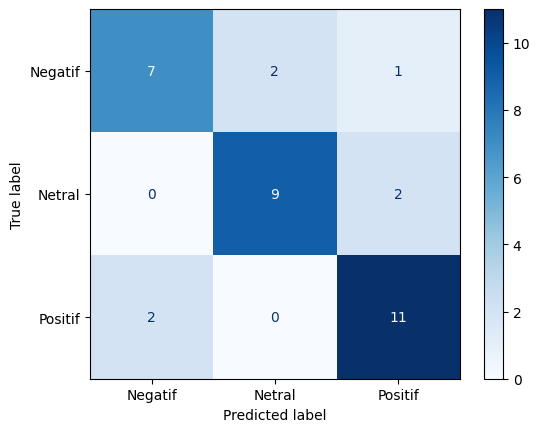

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test,
    display_labels=['Negatif','Netral','Positif'],
    cmap='Blues'
)

plt.show()

5 FOLD CROSS VALIDATION

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', model)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Accuracy tiap fold :", scores)
print("Rata-rata Accuracy :", scores.mean())
print("Standar Deviasi    :", scores.std())

Accuracy tiap fold : [0.82352941 0.79411765 0.70588235 0.79411765 0.66666667]
Rata-rata Accuracy : 0.7568627450980392
Standar Deviasi    : 0.059924340352690675


In [ ]:
def prediksi_sentimen(kalimat):
    # preprocessing
    kalimat = kalimat.lower()
    kalimat = cleaning(kalimat)
    kalimat = normalisasi_text(kalimat)

    tokens = kalimat.split()
    tokens = [kata for kata in tokens if kata not in stop_words]

    stemmed = ' '.join(stemmer.stem(kata) for kata in tokens)

    # TF-IDF
    vector = vectorizer.transform([stemmed])

    # Prediksi
    hasil = model.predict(vector)[0]

    if hasil == -1:
        return "Negatif"
    elif hasil == 0:
        return "Netral"
    else:
        return "Positif"

In [ ]:
kalimat = input("Masukkan kalimat: ")

print("Prediksi:", prediksi_sentimen(kalimat))

Masukkan kalimat: kurang
Prediksi: Negatif
